# NLP - Prova 1

Nesta prova, utilizaremos um dataset fornecido por uma empresa de e-commerce. Trata-se de um dataset que contém reviews de pedidos feitos na Internet ou através do aplicativo. Cada review tem uma nota (*score*) que vai de 1 (muito ruim) a 5 (muito bom). Também, cada review tem uma mensagem deixada pelo cliente, que pode esclarecer o que levou à atribuição da nota. O dataset é o seguinte:

In [1]:
import pandas as pd 
df = pd.read_csv('reviews.csv')
df.head()

,review_id,review_score,review_comment_message
0,e64fb393e7b32834bb789ff8bb30750e,5,Recebi bem antes do prazo estipulado.
1,f7c4243c7fe1938f181bec41a392bdeb,5,Parabéns lojas lannister adorei comprar pela I...
2,8670d52e15e00043ae7de4c01cc2fe06,4,aparelho eficiente. no site a marca do aparelh...
3,4b49719c8a200003f700d3d986ea1a19,4,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
4,3948b09f7c818e2d86c9a546758b2335,5,"Vendedor confiável, produto ok e entrega antes..."


A empresa, porém, gostaria de saber quais são os aspectos em que pode melhorar. Para fazer isso, jogou todos os reviews em um LLM (o procedimento para isso está em `consultar_llm.py`, que acompanha este notebook), e então coletou as respostas. Em sua execução, o LLM retornou o seguinte:

## RESPOSTA DO LLM

Para identificar os elementos mais elogiados e reclamados, vou analisar as avaliações buscando palavras-chave e temas recorrentes.

**Elogios Mais Comuns:**

*   **Entrega Rápida/No Prazo:** Este é o elogio mais frequente. Termos como "chegou antes do prazo", "entrega rápida", "no prazo" aparecem repetidamente.
*   **Produto Bom/Excelente Qualidade:** Muitos clientes expressam satisfação com a qualidade do produto em si. Palavras como "excelente", "bom", "perfeito", "recomendo", "atendeu minhas expectativas", "cumpre o que promete" são comuns.
*   **Bom Atendimento/Comunicação:** Alguns clientes elogiam a comunicação clara e eficiente com o vendedor.
*   **Embalagem:** Alguns clientes elogiaram a forma como o produto foi embalado.

**Reclamações Mais Comuns:**

*   **Não Recebimento do Produto:** Esta é a reclamação mais grave e frequente. Várias avaliações mencionam "não recebi o produto" ou "ainda não recebi".
*   **Atraso na Entrega:** Mesmo quando o produto é entregue, o atraso é uma reclamação comum.
*   **Produto com Defeito/Danificado:** Alguns clientes relatam receber produtos com defeito, amassados ou com peças faltando.
*   **Produto Errado:** Alguns clientes relatam ter recebido o produto errado.
*   **Problemas com a Compra/Cancelamento:** Alguns clientes relatam problemas com o cancelamento da compra.
*   **Problemas com a Comunicação:** Alguns clientes reclamam da dificuldade em se comunicar com o vendedor após a compra ou da falta de resposta às suas dúvidas.
*   **Voltagem Errada:** Um cliente reclamou que o produto veio com a voltagem errada.
*   **Qualidade do Produto Abaixo do Esperado:** Alguns clientes expressam insatisfação com a qualidade do produto, mencionando material ruim, acabamento imperfeito ou falsificação.
*   **Problemas com a Entrega pelos Correios:** Um cliente reclamou do serviço dos correios.

**Resumo:**

*   **Elogios:** Entrega rápida/no prazo e boa qualidade do produto são os pontos fortes.
*   **Reclamações:** Problemas com a entrega (não recebimento, atraso) e produtos com defeito/qualidade inferior são os principais pontos fracos.

**Recomendações:**

A empresa deve priorizar a melhoria dos processos de entrega para garantir que os produtos cheguem aos clientes no prazo e em perfeitas condições. Além disso, deve investir no controle de qualidade dos produtos e na comunicação com os clientes para resolver problemas de forma rápida e eficiente.


## Discussão

Mesmo que o LLM possa dar pistas importantes para o desenvolvimento desta solução, há um problemaa fundamental em simplesmente "acreditar" nessa resposta: ela não tem base em dados nem em uma metodologia científica, então é impossível criticá-la, replicá-la ou saber de suas limitações.

A tarefa neste exercício é encontrar dados, usando metodologias clássicas de NLP, que corroborem ou que contradigam a conclusão trazida pelo LLM.


# Exercícios

## Exercício 1

Faça e avalie (usando uma métrica) um modelo preditivo baseado no modelo Bag-of-Words capaz de prever, à partir do texto do review, se ele será positivo (notas 4 ou 5) ou negativo (notas 1, 2 ou 3). Use estratégias adequadas para mostrar que o modelo não está enviesado (por exemplo, retornando sempre 'positivo' para o review). Justifique todas as suas decisões (tipo de vetorizador, tipo de classificador, métrica(s) usada(s) para avaliação) em comentários no código.

Dica: `df['positivo'] = df['review_score'].apply(lambda x: x > 3)`

Accuracy: 0.90
[[0.82512733 0.17487267]
 [0.06455913 0.93544087]]


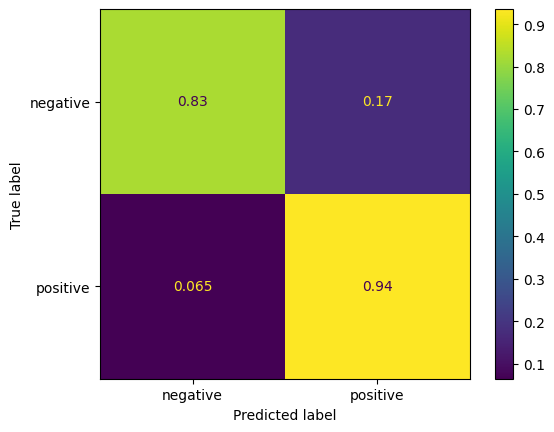

In [2]:
#exercicio1
#não apague o comentário acima!!!
# Faça todo o seu código (e também os comentários) nesta célula!

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,  ConfusionMatrixDisplay

df['positive'] = df['review_score'].apply(lambda x: x>3)

model = Pipeline([
    # Vamos usar o CountVectorizer com binary=true para vetorização de texto.
    # Esse vetorizador avalia a presença ou ausência de palavras de maneira binária em um documento, assim cada linha do vetorizador (correspondente a um documento) é uma "bag-of-words".
    ('vectorizer', CountVectorizer(binary=True)),
    # Como modelo, usaremos a Regressão Logística.
    # Ela oferece uma distribuição mais contínua de probabilidades, reduzindo a binariedade das decisões. 
    ('classifier', LogisticRegression())
])

X_train, X_test, y_train, y_test = train_test_split(df['review_comment_message'], df['positive'], test_size=0.2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Para mostrar que o modelo não está enviesado, vamos utilizar uma matriz de confusão.
# A matriz de confusão permite que observemos a distribuição de verdadeiros positivos, falsos positivos, verdadeiros negativos e falsos negativos.
# Uma proporção equilibrada entre falsos positivos e falsos negativos é um indicativo de baixo enviesamento.
# No nosso caso, apesar de haver uma menor existência de falsos positivos em comparação a falsos negativos, isso não é comprometedor para o viés.
c = confusion_matrix(y_test, y_pred, normalize='true')
print(c)
_ = ConfusionMatrixDisplay(c, display_labels=['negative', 'positive']).plot()
# Caso houvesse um desbalanço significativo dos dados, seria necessário rebalancear a proporção entre diferentes categorias de dados na base de teste.

## Exercício 2

Analise seu modelo e encontre quais são as palavras e/ou n-gramas que são melhores preditoras do número de estrelas (alto ou baixo) recebido um review (dica: você pode usar `pipeline[:-1].get_feature_names_out()` para encontrar uma lista com todos os tokens do seu vocabulário). Ao usar elementos do sklearn, use um comentário no código para explicar o que esses elementos significam e como eles podem apontar para o poder preditivo de cada palavra (ou n-grama). Por fim, use comentários no código para explicar como suas descobertas corroboram, contradizem, ou relativizam o que foi proposto pelo LLM.

In [ ]:
#exercicio2
#não apague o comentário acima!!!
# Faça todo o seu código (e também os comentários) nesta célula!

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.pipeline import Pipeline

features = model[:-1].get_feature_names_out()

pipeline = Pipeline([
    ('vectorizer', CountVectorizer(
        max_df=0.7,
        min_df=2,
    )),
    ('lda',
     LatentDirichletAllocation(
         n_components=10,
         max_iter=300,
         random_state=42,
     )),
])

pipeline.fit(features)

lda_output = pipeline.transform(features)
lda_model = pipeline.named_steps['lda']
feature_names = pipeline.named_steps['vectorizer'].get_feature_names_out()

# Print the most prominent words in each topic
# Print the number of documents whose most prominent topic is this one
most_prominent_topic = lda_output.argmax(axis=1)
for topic_idx, topic in enumerate(lda_model.components_):
    num_documents = (most_prominent_topic == topic_idx).sum()
    print(f"Topic {topic_idx} ({num_documents} documents):")
    print(" ".join([feature_names[i] for i in topic.argsort()[:-11:-1]]))

ValueError: After pruning, no terms remain. Try a lower min_df or a higher max_df.

# Rubricas e auto-avaliação assistida por IA

Este teste tem duas questões. Porém, são questões bastante complexas. Para verificar se você não esqueceu de nada em nenhuma questão, você pode usar o script `autoavaliacao.py`.

Cada um dos ítens cumpridos corretamente nas rubricas disponíveis em `autoavaliacao.py` terão o mesmo valor nas questões (1/8 na questão 1, 1/4 na questão 2). Um ítem cumprido parcialmente vale metade dos pontos. Um ítem feito errado não vale pontos. Cada uma das questões tem o mesmo valor (50% do total).

**IMPORTANTE**: o fato de o LLM dizer que um ítem da rubrica foi cumprido, não significa que ele **realmente** foi cumprido. O LLM avalia apenas se o ítem **existe**. O LLM é uma **ferramenta** e a sua utilidade depende do **seu** julgamento crítico.

Após o término da prova, salve seu notebook e entregue no Blackboard.

## Avaliação da prova

Se desejar, comente os pontos abaixo:

**Experiência da prova**: ao fazer esta prova, me senti...

**Dificuldades técnicas ou de compreensão do enunciado**: ...

**O script de auto-avaliação me ajudou**: sim, não, em partes...?